In [ ]:
import pandas as pd
import numpy as np 
import statsmodels.api as sm
import matplotlib.pyplot as plt 
from linearmodels.iv import IV2SLS

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('CaseData2026.csv', delimiter=';')

df.groupby('test')['purchase'].mean() # conversion rates by group

df

,test,purchase,impressions,impressions_mc
0,0,0,6,2.80114
1,1,0,3,-0.19886
2,1,0,3,-0.19886
3,0,0,4,0.80114
4,1,0,0,-3.19886
...,...,...,...,...
49995,1,0,4,0.80114
49996,0,0,8,4.80114
49997,1,0,2,-1.19886
49998,1,0,3,-0.19886


In [3]:
df.groupby('test')['impressions'].describe() #impression dist. by group

,count,mean,std,min,25%,50%,75%,max
test,,,,,,,,
0,24928.0,3.196967,2.405838,0.0,1.0,3.0,5.0,17.0
1,25072.0,3.200742,2.401858,0.0,1.0,3.0,5.0,15.0


# 1: non-compliance check

In [4]:
treatment_group = df[df['test'] == 1]
control_group = df[df['test'] == 0]

treatment_no_exposure = treatment_group[treatment_group['impressions'] == 0]
treatment_with_exposure = treatment_group[treatment_group['impressions'] > 0]

compliance_rate_treatment = len(treatment_with_exposure) / len(treatment_group)
non_compliance_rate = len(treatment_no_exposure) / len(treatment_group)

print(f"treatment group size: {len(treatment_group)}")
print(f"treatment group with impressions > 0 (compliers): {len(treatment_with_exposure)}")
print(f"treatment group with impressions = 0 (non-compliers): {len(treatment_no_exposure)}")
print(f"compliance rate in treatment: {compliance_rate_treatment:.4f} ({compliance_rate_treatment*100:.2f}%)")
print(f"non-compliance rate: {non_compliance_rate:.4f} ({non_compliance_rate*100:.2f}%)")


control_no_exposure = control_group[control_group['impressions'] == 0]
print(f'control group with 0 ghost impressions: {len(control_no_exposure) / len(control_group)}')

treatment group size: 25072
treatment group with impressions > 0 (compliers): 19694
treatment group with impressions = 0 (non-compliers): 5378
compliance rate in treatment: 0.7855 (78.55%)
non-compliance rate: 0.2145 (21.45%)
control group with 0 ghost impressions: 0.2159017971758665


# 2: estimate effects

ITT, LATE

skip ATET since it's biased but discuss in paper

(we skip ATE since we cannot estimate it)

In [5]:
#bin var treatment indicator (actually saw ads)
df['saw_ads'] = ((df['test'] == 1) & (df['impressions'] > 0)).astype(int)

#ITT
itt_control = df[df['test'] == 0]['purchase'].mean()
itt_treatment = df[df['test'] == 1]['purchase'].mean()
itt_effect = itt_treatment - itt_control

print(f'control group conversion rate: {itt_control}')
print(f'treatment group conversion rate: {itt_treatment}\nITT effect: {itt_effect}')

#ITT with regression (for st err)
X_itt = sm.add_constant(df['test'])
model_itt = sm.OLS(df['purchase'], X_itt).fit(cov_type='HC1') #robust SEs 
print(f'regression:\n{model_itt.summary().tables[1]}')


control group conversion rate: 0.024029204107830552
treatment group conversion rate: 0.028677409061901724
ITT effect: 0.004648204954071172
regression:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0240      0.001     24.773      0.000       0.022       0.026
test           0.0046      0.001      3.245      0.001       0.002       0.007


In [6]:
#LATE via IV
#instrument: test, endo: saw_ads, outcome: purchase 

df_iv = df[['purchase', 'saw_ads', 'test']].copy()
df_iv['const'] = 1 

iv_model = IV2SLS(
    dependent=df_iv['purchase'],
    exog=df_iv['const'],
    endog=df_iv['saw_ads'],
    instruments=df_iv['test'],
).fit(cov_type='robust')

iv_model.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:               purchase   R-squared:                      0.0015
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0015
No. Observations:               50000   F-statistic:                    10.544
Date:                Wed, Feb 04 2026   P-value (F-stat)                0.0012
Time:                        17:58:29   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
==============================================================================
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0240     0.0010     24.774     0.0000      0.0221      0.0259
saw_ads        0.0059     0.0018     3.2471     0.0012      0.0023      0.0095
==============================================================================

Endogenous: saw_ads
Instruments: test
Robust Covariance (Heteroskedastic)
Debiased: False
"""

In [7]:
#manual LATE calc: LATE = ITT / compliance rate 
compliance_diff = df[df['test'] == 1]['saw_ads'].mean() - df[df['test'] == 0]['saw_ads'].mean()
late = itt_effect / compliance_diff 

print(f'itt effect: {itt_effect}\ncompliance diff: {compliance_diff}\nLATE: {late}')

itt effect: 0.004648204954071172
compliance diff: 0.7854977664326739
LATE: 0.005917527907406948


# 3: analysis 

estimate CATEs

In [8]:
#create impression bins for strat analysis
df['imp_bins'] = pd.cut(df['impressions'], bins=[-1, 0, 1, 2, 3, 5, 10, 20], labels=['0', '1', '2', '3', '4-5', '6-10', '11+'])

#calc ITT bu imp bin
cate_by_bin = df.groupby(['imp_bins', 'test'])['purchase'].agg(['mean', 'count', 'std']).unstack()
cate_by_bin.columns = ['_'.join(map(str, col)) for col in cate_by_bin.columns] #convert to str before joining
cate_by_bin['ITT'] = cate_by_bin['mean_1'] - cate_by_bin['mean_0']
cate_by_bin['n_total'] = cate_by_bin['count_0'] + cate_by_bin['count_1']

cate_by_bin[['mean_0', 'mean_1', 'ITT', 'n_total']].round(4)

,mean_0,mean_1,ITT,n_total
imp_bins,,,,
0,0.0000,0.0000,0.0000,10760
1,0.0000,0.0000,0.0000,2932
2,0.0000,0.0000,0.0000,5860
3,0.0000,0.0000,0.0000,7830
4-5,0.0000,0.0001,0.0001,14039
6-10,0.1302,0.1564,0.0262,8478
11+,1.0000,1.0000,0.0000,101


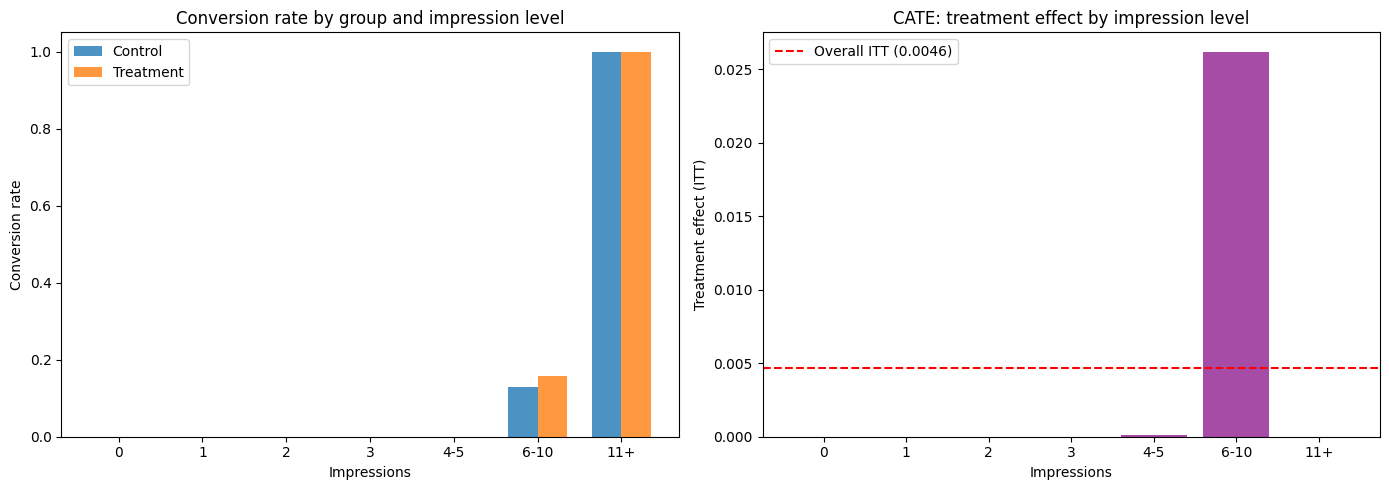

In [9]:
#vis CATE by imp bins
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#plot 1: conv rates by group and impression level
ax1 = axes[0]
x = range(len(cate_by_bin))
width = 0.35
ax1.bar([i - width/2 for i in x], cate_by_bin['mean_0'], width, label='Control', alpha=0.8)
ax1.bar([i + width/2 for i in x], cate_by_bin['mean_1'], width, label='Treatment', alpha=0.8)
ax1.set_xlabel('Impressions')
ax1.set_ylabel('Conversion rate')
ax1.set_title('Conversion rate by group and impression level')
ax1.set_xticks(x)
ax1.set_xticklabels(cate_by_bin.index)
ax1.legend()

#plot 2: CATE (treatment effect) by impression level
ax2 = axes[1]
ax2.bar(x, cate_by_bin['ITT'], color='purple', alpha=0.7)
ax2.axhline(y=itt_effect, color='red', linestyle='--', label=f'Overall ITT ({itt_effect:.4f})')
ax2.set_xlabel('Impressions')
ax2.set_ylabel('Treatment effect (ITT)')
ax2.set_title('CATE: treatment effect by impression level')
ax2.set_xticks(x)
ax2.set_xticklabels(cate_by_bin.index)
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
#regression with interaction to test heterogeneity
#model: purchase ~ test + impressions + test*impressions

df['test_x_imp'] = df['test'] * df['impressions']
X_interact = sm.add_constant(df[['test', 'impressions', 'test_x_imp']])
model_interact = sm.OLS(df['purchase'], X_interact).fit(cov_type='HC1')

print(model_interact.summary().tables[1])

print(f"- base effect of treatment (at 0 impressions): {model_interact.params['test']}")
print(f"- additional effect per impression: {model_interact.params['test_x_imp']}")
print(f"- interaction significant? p = {model_interact.pvalues['test_x_imp']}")

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0533      0.002    -27.571      0.000      -0.057      -0.050
test           -0.0067      0.003     -2.420      0.016      -0.012      -0.001
impressions     0.0242      0.001     28.343      0.000       0.023       0.026
test_x_imp      0.0035      0.001      2.866      0.004       0.001       0.006
- base effect of treatment (at 0 impressions): -0.0066651281558449925
- additional effect per impression: 0.003506070910565647
- interaction significant? p = 0.004154874372134771


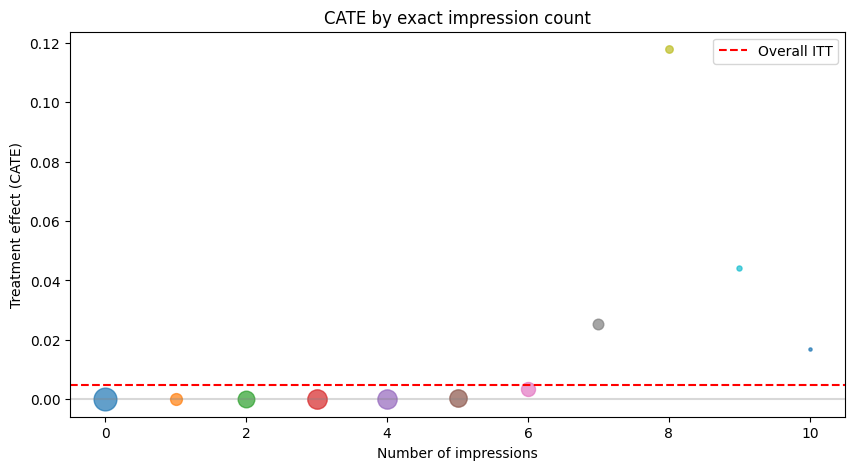

In [11]:
#alt: CATE using continuous impressions (for compliers only)
#compare treatment compliers vs control at each impression level

fig, ax = plt.subplots(figsize=(10, 5))

for imp in range(0, 11):
    ctrl = df[(df['test'] == 0) & (df['impressions'] == imp)]['purchase'].mean()
    treat = df[(df['test'] == 1) & (df['impressions'] == imp)]['purchase'].mean()
    n_ctrl = len(df[(df['test'] == 0) & (df['impressions'] == imp)])
    n_treat = len(df[(df['test'] == 1) & (df['impressions'] == imp)])
    
    if n_ctrl > 100 and n_treat > 100:  # only plot if sufficient sample
        ax.scatter(imp, treat - ctrl, s=min(n_ctrl, n_treat)/20, alpha=0.7)
        
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axhline(y=itt_effect, color='red', linestyle='--', label=f'Overall ITT')
ax.set_xlabel('Number of impressions')
ax.set_ylabel('Treatment effect (CATE)')
ax.set_title('CATE by exact impression count')
ax.legend()
plt.show()

# 4: profitability analysis

In [12]:
contribution_per_purchase = 200
cost_per_impression = 100 / 1_000

late_effect = 0.0059 
itt_effect = 0.00465

avg_impressions_treatment = df[df['test'] == 1]['impressions'].mean()
avg_impressions_control = df[df['test'] == 0]['impressions'].mean()  # ghost impressions
avg_impressions_compliers = df[(df['test'] == 1) & (df['impressions'] > 0)]['impressions'].mean()

print(f"contribution per purchase: {contribution_per_purchase} NOK")
print(f"cost per impression: {cost_per_impression} NOK")
print(f"average impressions (treatment): {avg_impressions_treatment:.2f}")
print(f"average impressions (compliers only): {avg_impressions_compliers:.2f}")


contribution per purchase: 200 NOK
cost per impression: 0.1 NOK
average impressions (treatment): 3.20
average impressions (compliers only): 4.07


In [13]:
# method 1: per-user analysis (ITT_based, conservative)

revenue_lift_per_user = itt_effect * contribution_per_purchase
cost_per_user = avg_impressions_treatment * cost_per_impression
net_contribution_per_user_itt = revenue_lift_per_user - cost_per_user


print(f'revenue lift per user: {revenue_lift_per_user}')
print(f'ad cost per user: {cost_per_user}')
print(f'net contribution per user: {net_contribution_per_user_itt}')
print(f'ROI: {(revenue_lift_per_user / cost_per_user - 1) * 100}')

revenue lift per user: 0.9299999999999999
ad cost per user: 0.32007418634333124
net contribution per user: 0.6099258136566688
ROI: 190.5576393475308


In [14]:
# method 2: per-complier analysis (LATE-based)

revenue_lift_per_complier = late_effect * contribution_per_purchase
cost_per_complier = avg_impressions_compliers * cost_per_impression
net_contribution_per_complier = revenue_lift_per_complier - cost_per_complier

print(f"revenue lift per complier: {revenue_lift_per_complier} NOK")
print(f"ad cost per complier: {cost_per_complier} NOK")
print(f"net contribution per complier: {net_contribution_per_complier} NOK")
print(f"ROI: {(revenue_lift_per_complier / cost_per_complier - 1) * 100}%")


revenue lift per complier: 1.18 NOK
ad cost per complier: 0.4074794353610237 NOK
net contribution per complier: 0.7725205646389762 NOK
ROI: 189.58516617029494%


In [15]:
# campaign-level calc

n_treatment = len(df[df['test'] == 1])
total_impressions_treatment = df[df['test'] == 1]['impressions'].sum()

total_revenue_lift = n_treatment * itt_effect * contribution_per_purchase
total_ad_cost = total_impressions_treatment * cost_per_impression
total_net_contribution = total_revenue_lift - total_ad_cost

print(f"users in treatment: {n_treatment}")
print(f"total impressions served: {total_impressions_treatment}")
print(f"expected additional conversions: {n_treatment * itt_effect}")
print(f"total revenue lift: {total_revenue_lift} NOK")
print(f"total ad cost: {total_ad_cost} NOK")
print(f"net contribution: {total_net_contribution} NOK")

users in treatment: 25072
total impressions served: 80249
expected additional conversions: 116.58479999999999
total revenue lift: 23316.96 NOK
total ad cost: 8024.900000000001 NOK
net contribution: 15292.059999999998 NOK


In [16]:
# sensitivity snalysis

#break-even contribution per purchase
breakeven_contribution = cost_per_user / itt_effect
print(f"break-even contribution per purchase:")
print(f"current: {contribution_per_purchase} NOK")
print(f"break-even: {breakeven_contribution} NOK")
print(f"margin of safety: {(contribution_per_purchase - breakeven_contribution) / contribution_per_purchase * 100}%")

#break-even ad cost per 1000 impressions
breakeven_cpm = (itt_effect * contribution_per_purchase) / avg_impressions_treatment * 1000
print(f"\nbreak-even CPM (cost per 1000 impressions):")
print(f"current: 100 NOK")
print(f"break-even: {breakeven_cpm} NOK")
print(f"margin of safety: {(breakeven_cpm - 100) / breakeven_cpm * 100}%")

#break-even treatment effect
breakeven_effect = cost_per_user / contribution_per_purchase
print(f"\nbreak-even treatment effect (ITT):")
print(f"current: {itt_effect*100}%")
print(f"break-even: {breakeven_effect*100}%")
print(f"margin of safety: {(itt_effect - breakeven_effect) / itt_effect * 100}%")

break-even contribution per purchase:
current: 200 NOK
break-even: 68.83315835340457 NOK
margin of safety: 65.58342082329771%

break-even CPM (cost per 1000 impressions):
current: 100 NOK
break-even: 290.55763934753077 NOK
margin of safety: 65.58342082329771%

break-even treatment effect (ITT):
current: 0.46499999999999997%
break-even: 0.16003709317166562%
margin of safety: 65.58342082329771%


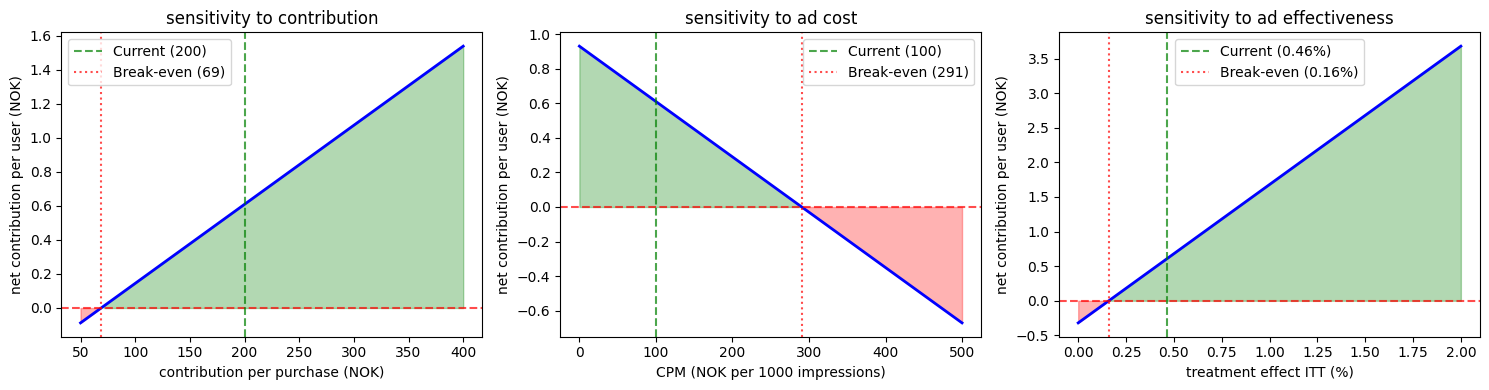

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#sensitivity to contribution per purchase
contributions = np.linspace(50, 400, 100)
net_by_contrib = [itt_effect * c - cost_per_user for c in contributions]
axes[0].plot(contributions, net_by_contrib, 'b-', linewidth=2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0].axvline(x=contribution_per_purchase, color='green', linestyle='--', alpha=0.7, label='Current (200)')
axes[0].axvline(x=breakeven_contribution, color='red', linestyle=':', alpha=0.7, label=f'Break-even ({breakeven_contribution:.0f})')
axes[0].set_xlabel('contribution per purchase (NOK)')
axes[0].set_ylabel('net contribution per user (NOK)')
axes[0].set_title('sensitivity to contribution')
axes[0].legend()
axes[0].fill_between(contributions, net_by_contrib, 0, where=[n > 0 for n in net_by_contrib], alpha=0.3, color='green')
axes[0].fill_between(contributions, net_by_contrib, 0, where=[n < 0 for n in net_by_contrib], alpha=0.3, color='red')

#sensitivity to CPM
cpms = np.linspace(0, 500, 100)
net_by_cpm = [itt_effect * contribution_per_purchase - avg_impressions_treatment * (c/1000) for c in cpms]
axes[1].plot(cpms, net_by_cpm, 'b-', linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.7, label='Current (100)')
axes[1].axvline(x=breakeven_cpm, color='red', linestyle=':', alpha=0.7, label=f'Break-even ({breakeven_cpm:.0f})')
axes[1].set_xlabel('CPM (NOK per 1000 impressions)')
axes[1].set_ylabel('net contribution per user (NOK)')
axes[1].set_title('sensitivity to ad cost')
axes[1].legend()
axes[1].fill_between(cpms, net_by_cpm, 0, where=[n > 0 for n in net_by_cpm], alpha=0.3, color='green')
axes[1].fill_between(cpms, net_by_cpm, 0, where=[n < 0 for n in net_by_cpm], alpha=0.3, color='red')

#sensitivity to treatment effect
effects = np.linspace(0, 0.02, 100)
net_by_effect = [e * contribution_per_purchase - cost_per_user for e in effects]
axes[2].plot(effects * 100, net_by_effect, 'b-', linewidth=2)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[2].axvline(x=itt_effect*100, color='green', linestyle='--', alpha=0.7, label=f'Current ({itt_effect*100:.2f}%)')
axes[2].axvline(x=breakeven_effect*100, color='red', linestyle=':', alpha=0.7, label=f'Break-even ({breakeven_effect*100:.2f}%)')
axes[2].set_xlabel('treatment effect ITT (%)')
axes[2].set_ylabel('net contribution per user (NOK)')
axes[2].set_title('sensitivity to ad effectiveness')
axes[2].legend()
axes[2].fill_between(effects * 100, net_by_effect, 0, where=[n > 0 for n in net_by_effect], alpha=0.3, color='green')
axes[2].fill_between(effects * 100, net_by_effect, 0, where=[n < 0 for n in net_by_effect], alpha=0.3, color='red')

plt.tight_layout()
plt.show()